In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probjax.utils.sdeint import sdeint


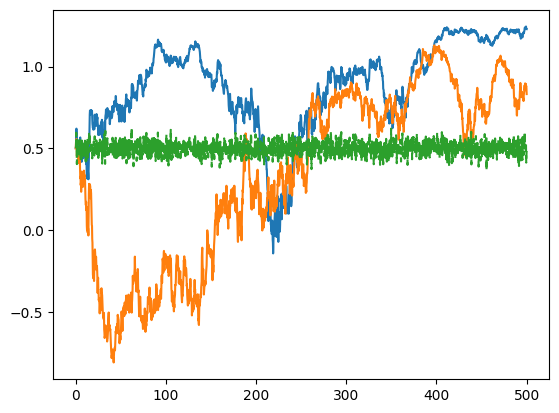

In [4]:

# Define the ODE
def f(t, x):
    return -(1 / 10)**2 * jnp.sin(x)*jnp.cos(x)**3

def g(t, x):
    return 1/10 * jnp.cos(x)**2

def f_true(Wt,t, x0):
    return jnp.arctan(1/10 * Wt + jnp.tan(x0))

# Define the initial condition
x0 = jnp.ones((1,))*0.5

# Define the time points to evaluate
t = jnp.linspace(0., 500., 2000)

# Solve the ODE
key = jax.random.PRNGKey(2)
x,W  = sdeint(key, f, g, x0, t, method="euler_maruyama", noise_type="diagonal", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f, g, x0, t, method="sri2", noise_type="diagonal", return_brownian=True)
y = f_true(W, t, x0)


# Plot the solution

plt.plot(t, x)
plt.plot(t, x2)
plt.plot(t, f_true(W , t, x0), "--")

In [3]:
d = 2
m = 2

def f2(t,x):
    return 0.5 * x*(1-x) * (1- 2*x)

def g2(t,x):
    return jnp.diag(x * (1-x))

def f2_true(Wt,t,x0):
    return 1/(1 + jnp.exp(-Wt + jnp.log(x0/(1-x0)).reshape(-1,2)))

x0 = jnp.array([0.5, 0.5])
t = jnp.linspace(0., 20., 300)
key = jax.random.PRNGKey(0)
x,W  = sdeint(key, f2, g2, x0, t, method="euler_maruyama", noise_type="general", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f2, g2, x0, t, method="milstein",noise_type="general", return_brownian=True)
y = f2_true(W, t, x0)

plt.plot(t, x[:,0])
plt.plot(t, x2[:,0])
plt.plot(t, f2_true(W , t, x0)[:,0])

plt.plot(t, x[:,1], '--', color='C0')
plt.plot(t, x2[:,1], '--', color='C1')
plt.plot(t, f2_true(W , t, x0)[:,1], '--', color='C2')

plt.ylim(0,1)

TypeError: mul got incompatible shapes for broadcasting: (4,), (2,).

In [5]:
from jax._src.flatten_util import ravel_pytree

In [6]:
def g2(t,x):
    return {"x":jnp.diag(x * (1-x))}

In [8]:
out = g2(0, jnp.array([0.5, 0.5]))
flatt_out, flatten_tree = ravel_pytree(out)

In [11]:
flatten_tree(flatt_out)

{'x': Array([[0.25, 0.  ],
        [0.  , 0.25]], dtype=float32)}